# Multi-Model Feature Selector Notebook

Runs **LOCO**, **coalition SHAP**, and **FFS** on the full VLST cohort. There is no unused outer test (playground / Part 5 70/30 is not used here).

- Models: `lr`, `rf`, `rf_b`, `cat`, `xgb`, `xgb_b`, `lgb`, optional `tabpfn`
- Objective: `pr_auc` only.
- **No unused outer test.** After de-leak, selectors never read a parked 70/30 test, so keeping one would throw away ~28 events. All 5,185 rows are split once: fit on `1 - INNER_VAL_SIZE`, score on `INNER_VAL_SIZE`. This catalogue still does **not** feed Part 4.
- **Selectors are independent.** LOCO, coalition SHAP, and FFS each pick their own candidate pool from a cheap fit-slice importance ranking. SHAP/FFS do **not** read LOCO’s selected names. Toggle any of them with `RUN_SELECTORS`.
- **FFS budget (paper protocol):** cheap-importance pool `FFS_CANDIDATE_POOL=24` × at most `FFS_MAX_STEPS=12`, then stop if PR-AUC stops rising (`FFS_MIN_GAIN=0`). There is no reduced / smoke budget.
- Final outputs include:
  - all unique selected features across all models/algorithms/metrics
  - common features shared by all models per algorithm

Delete any cached `loco_*.csv` / `shap_*.csv` / `ffs_*.csv` from an older test-scored run before executing on Kaggle (`USE_CACHE=False`). Stored outputs in this notebook are the **pre-anti-leakage** run (TSSI dropped, `WBC` still selected). New code writes to `model_feature_selectors_antileak/` so those CSVs stay until reports are updated.


In [ ]:
import json
import os
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    f1_score,
    fbeta_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

# -------------------------------
# Runtime controls
# -------------------------------
# Cached CSVs from an older test-scored export are leaky — do not resume them.
USE_CACHE = False
USE_GPU = True  # set False to force CPU for all GPU-capable models
INNER_VAL_SIZE = 0.2  # fraction of the *full* cohort used as the selection scoreboard

RANDOM_STATE = 42
# No TEST_SIZE: discovery uses every row (see split cell).
TARGET_COL = "Stent thrombosis"
DROP_FEATURES = ["Time since stent implantation", "WBC"]
ID_COLS = ["NO.", "Name"]

SCORINGS = ["pr_auc"]  # discovery metric; F1/F2 dropped to cut the run 3×
RUN_SELECTORS = {"LOCO": True, "SHAP": True, "FFS": True}
BETA_F2 = 2.0
THRESHOLD_GRID_POINTS = 199

PRIORITY_FEATURES = [
    "Age, years",
    "Male sex",
    "Current drinking",
    "Diabetes mellitus",
    "aspirin",
    "Hypertension",
    "Dapt",
    "Dyslipidemia",
    "HbA1C",
    "Clopidogrel",
    "Current smoker",
]

# GPU detection (Kaggle T4: enable GPU in notebook settings)
try:
    import torch

    CUDA_AVAILABLE = bool(USE_GPU and torch.cuda.is_available())
    DEVICE_NAME = torch.cuda.get_device_name(0) if CUDA_AVAILABLE else "cpu"
except Exception:
    CUDA_AVAILABLE = False
    DEVICE_NAME = "cpu"

CATBOOST_TASK_TYPE = "GPU" if CUDA_AVAILABLE else "CPU"
XGB_DEVICE = "cuda" if CUDA_AVAILABLE else "cpu"
LGB_DEVICE = "gpu" if CUDA_AVAILABLE else "cpu"
TABPFN_DEVICE = "cuda" if CUDA_AVAILABLE else "cpu"

# Paper protocol (single budget; no reduced / smoke switch).
FEATURE_TOPK = 20
SHAP_UNIVERSE = 40
SHAP_N_PERM = 40
SHAP_N_INSTANCES = 64
SHAP_N_BACKGROUND = 64
SHAP_N_BG_DRAWS = 3
LOCO_MAX_FEATURES = 60  # cap after cheap fit-slice importance, not column order
FFS_CANDIDATE_POOL = 24  # independent cheap-importance pool (not LOCO)
FFS_MAX_STEPS = 12
FFS_MIN_GAIN = 0.0  # stop when adding a feature does not raise PR-AUC
SELECTOR_CAT_ITERS = 400
SELECTOR_XGB_ROUNDS = 400
SELECTOR_LGB_ROUNDS = 400

_ffs_hi = FFS_CANDIDATE_POOL
_ffs_lo = FFS_CANDIDATE_POOL - FFS_MAX_STEPS + 1
FFS_FITS_PER_MODEL = sum(range(_ffs_lo, _ffs_hi + 1)) if _ffs_lo > 0 else 0

print("USE_CACHE:", USE_CACHE, "| INNER_VAL_SIZE:", INNER_VAL_SIZE)
print("SCORINGS:", SCORINGS, "| RUN_SELECTORS:", RUN_SELECTORS)
print(
    f"FFS budget: pool={FFS_CANDIDATE_POOL} steps<={FFS_MAX_STEPS} "
    f"→ {FFS_FITS_PER_MODEL} refits/model before early stop"
)
print("GPU:", CUDA_AVAILABLE, "|", DEVICE_NAME)
print("CatBoost:", CATBOOST_TASK_TYPE, "| XGB:", XGB_DEVICE, "| LGB:", LGB_DEVICE, "| TabPFN:", TABPFN_DEVICE)


USE_CACHE: False | INNER_VAL_SIZE: 0.2
SCORINGS: ['pr_auc'] | RUN_SELECTORS: {'LOCO': True, 'SHAP': True, 'FFS': True}
FFS budget: pool=24 steps<=12 → 222 refits/model before early stop
GPU: True | Tesla T4
CatBoost: GPU | XGB: cuda | LGB: gpu | TabPFN: cuda


In [2]:
# -------------------------------
# Paths and data loaders (same CSV as the rest of the paper; split is local to this notebook)
# -------------------------------
KAGGLE_RAW_CSV = "/kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv"
KAGGLE_OUT_DIR = "/kaggle/working/model_feature_selectors_antileak"


def _find_repo_root() -> Path:
    here = Path.cwd().resolve()
    for d in (here, *here.parents):
        if (d / "data" / "raw" / "VLST.csv").is_file():
            return d
    raise FileNotFoundError("Could not locate data/raw/VLST.csv above the current working directory.")


# Detect Kaggle vs local
IS_KAGGLE = Path("/kaggle/working").is_dir()
if IS_KAGGLE:
    RAW_PATH = Path(os.environ.get("VLST_RAW_CSV", KAGGLE_RAW_CSV))
    OUT_DIR = Path(os.environ.get("VLST_RESULT_DIR", KAGGLE_OUT_DIR))
else:
    REPO_ROOT = _find_repo_root()
    RAW_PATH = Path(os.environ.get("VLST_RAW_CSV", REPO_ROOT / "data" / "raw" / "VLST.csv"))
    OUT_DIR = Path(os.environ.get("VLST_RESULT_DIR", REPO_ROOT / "data" / "result" / "model_feature_selectors_antileak"))

OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Runtime:", "Kaggle" if IS_KAGGLE else "local")
print("RAW_PATH:", RAW_PATH)
print("OUT_DIR:", OUT_DIR)



def _load_stent_encoding():
    """Import the shared 9-level stent-brand encoder.

    On Kaggle the repo tree is usually missing, so this falls back to an
    in-notebook copy of ``code/modeling/tools/stent_encoding.py``.
    """
    import re
    import sys
    from pathlib import Path

    search_roots = [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    for extra in (
        Path("/kaggle/working"),
        Path("/kaggle/input"),
        Path("/kaggle/usr/lib"),
    ):
        if extra.is_dir():
            search_roots.append(extra)
            search_roots.extend(extra.glob("*"))

    for d in search_roots:
        for tools in (
            d / "code" / "modeling" / "tools",
            d / "modeling" / "tools",
            d,
        ):
            if (Path(tools) / "stent_encoding.py").is_file():
                tools = Path(tools)
                if str(tools) not in sys.path:
                    sys.path.insert(0, str(tools))
                try:
                    from stent_encoding import (
                        encode_stent_brand_column,
                        coerce_stent_class_flags,
                        fit_stent_brand_encoder,
                        transform_stent_brand_column,
                    )
                except ImportError:
                    continue
                print("Stent encoder: imported from", tools / "stent_encoding.py")
                return (
                    encode_stent_brand_column,
                    coerce_stent_class_flags,
                    fit_stent_brand_encoder,
                    transform_stent_brand_column,
                )

    print("Stent encoder: using in-notebook fallback (Kaggle / no repo tree).")

    STENT_BRAND_RAW_COL = "Stent type-SES"
    STENT_CLASS_FLAG_COLS = ("PES", "ZES", "EVS")
    STENT_BRAND_MIN_COUNT = 30
    _BRAND_ALIASES = {
        "xiencex": "xiencev",
        "resolut": "resolute",
        "parnter": "partner",
        "endeavor": "endeavor",
        "cypher": "cypher",
    }

    def canonicalize_stent_brand(value):
        if pd.isna(value) or str(value).strip() == "":
            return "missing"
        s = str(value).strip().replace("：", ":").lower()
        s = re.sub(r"\s+", "", s)
        if ":" in s:
            s = s.split(":")[-1]
        for sep in ("，", ",", "/"):
            if sep in s:
                s = s.split(sep)[0]
        return _BRAND_ALIASES.get(s, s)

    def collapse_rare_brands(series, min_count=STENT_BRAND_MIN_COUNT):
        counts = series.value_counts()
        rare = set(counts[counts < min_count].index)
        if not rare:
            return series
        return series.where(~series.isin(rare), "other")

    def encode_stent_brand_column(df, *, raw_col=STENT_BRAND_RAW_COL, min_count=STENT_BRAND_MIN_COUNT, inplace=False):
        out = df if inplace else df.copy()
        meta = {
            "column": raw_col,
            "n_raw": 0,
            "n_levels": 0,
            "min_count": min_count,
            "applied": False,
            "value_counts": {},
        }
        if raw_col not in out.columns:
            return out, meta
        raw = out[raw_col]
        if pd.api.types.is_numeric_dtype(raw):
            meta["n_raw"] = int(raw.nunique(dropna=True))
            meta["n_levels"] = meta["n_raw"]
            return out, meta
        n_raw = int(raw.nunique(dropna=True))
        encoded = collapse_rare_brands(raw.map(canonicalize_stent_brand), min_count)
        out[raw_col] = encoded.astype("object")
        meta.update({
            "n_raw": n_raw,
            "n_levels": int(encoded.nunique(dropna=True)),
            "applied": True,
            "value_counts": encoded.value_counts().to_dict(),
        })
        return out, meta

    def coerce_stent_class_flags(df):
        out = df
        for col in STENT_CLASS_FLAG_COLS:
            if col not in out.columns:
                continue
            s = pd.to_numeric(out[col], errors="coerce").fillna(0).astype(int)
            bad = ~s.isin([0, 1])
            if bad.any():
                raise ValueError(f"{col}: expected 0/1 after coercion, got {out.loc[bad, col].unique()[:10]}")
            out[col] = s
        return out

    def fit_stent_brand_encoder(series, min_count=STENT_BRAND_MIN_COUNT):
        meta = {
            "min_count": min_count,
            "numeric": False,
            "kept": set(),
            "n_raw": 0,
            "n_levels": 0,
            "applied": False,
        }
        if pd.api.types.is_numeric_dtype(series):
            n = int(series.nunique(dropna=True))
            meta.update({"numeric": True, "n_raw": n, "n_levels": n})
            return meta
        canon = series.map(canonicalize_stent_brand)
        counts = canon.value_counts()
        kept = set(counts[counts >= min_count].index)
        meta.update({
            "kept": kept,
            "n_raw": int(series.nunique(dropna=True)),
            "n_levels": int(len(kept) + int((counts < min_count).any())),
            "applied": True,
        })
        return meta

    def transform_stent_brand_column(frame, codebook, raw_col=STENT_BRAND_RAW_COL, inplace=False):
        out = frame if inplace else frame.copy()
        if raw_col not in out.columns or codebook.get("numeric") or not codebook.get("applied"):
            return out
        canon = out[raw_col].map(canonicalize_stent_brand)
        kept = codebook["kept"]
        out[raw_col] = canon.where(canon.isin(kept), "other").astype("object")
        return out

    return (
        encode_stent_brand_column,
        coerce_stent_class_flags,
        fit_stent_brand_encoder,
        transform_stent_brand_column,
    )


(
    encode_stent_brand_column,
    coerce_stent_class_flags,
    fit_stent_brand_encoder,
    transform_stent_brand_column,
) = _load_stent_encoding()


STENT_BRAND_COL = "Stent type-SES"
CLINICAL_QUANTIZE_PLACES = {"Cre": 0, "CaI": 2, "Fiberinogen": 1, "Fast-Glu": 1}


def quantize_clinical_precision(frame, places_by_column):
    applied = {}
    for column, places in places_by_column.items():
        if column not in frame.columns or not pd.api.types.is_numeric_dtype(frame[column]):
            continue
        before = pd.to_numeric(frame[column], errors="coerce")
        rounded = before.round(int(places))
        frame[column] = rounded
        applied[column] = {"places": int(places), "n_changed": int((before != rounded).fillna(False).sum())}
    return applied


def encode_stent_on_fold(X_tr, X_va, raw_col=STENT_BRAND_COL, min_count=30):
    if raw_col not in X_tr.columns:
        return X_tr, X_va, {"applied": False, "n_raw": 0, "n_levels": 0, "min_count": min_count}
    codebook = fit_stent_brand_encoder(X_tr[raw_col], min_count=min_count)
    return (
        transform_stent_brand_column(X_tr, codebook, raw_col=raw_col),
        transform_stent_brand_column(X_va, codebook, raw_col=raw_col),
        codebook,
    )


def load_cleaned_frame(raw_path: Path):
    """File-level cleaning only. Stent collapse and scaler are fit after the split."""
    df = pd.read_csv(raw_path)
    df = coerce_stent_class_flags(df)
    _q = quantize_clinical_precision(df, CLINICAL_QUANTIZE_PLACES)
    print(
        "Clinical quantization (file-level):",
        ", ".join(f"{c}->{m['places']}dp ({m['n_changed']} changed)" for c, m in _q.items()) or "(none)",
    )
    df = df.drop(columns=[c for c in ID_COLS if c in df.columns])
    dropped = [c for c in DROP_FEATURES if c in df.columns]
    df = df.drop(columns=dropped)
    print("Dropped leakage-style feature(s):", dropped)
    df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce").astype(int)
    return df


def encode_object_columns_from_train(train_df, test_df):
    train_out = train_df.copy()
    test_out = test_df.copy()
    for col in train_out.columns:
        train_s, test_s = train_out[col], test_out[col]
        if not (
            pd.api.types.is_object_dtype(train_s)
            or pd.api.types.is_object_dtype(test_s)
            or str(train_s.dtype) in ("category", "string")
        ):
            continue
        levels = pd.Index(pd.unique(train_s.dropna()))
        mapping = {value: index for index, value in enumerate(levels)}
        train_out[col] = train_s.map(mapping).astype(float)
        test_out[col] = test_s.map(mapping).astype(float)
    return train_out, test_out


def _feature_columns(df):
    feature_cols = [c for c in df.columns if c != TARGET_COL]
    numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = df[feature_cols].select_dtypes(include=["object"]).columns.tolist()
    binary_cols = [
        c for c in numeric_cols
        if set(df[c].dropna().unique()).issubset({0, 1}) and df[c].nunique(dropna=True) <= 2
    ]
    continuous_cols = [c for c in numeric_cols if c not in binary_cols]
    return feature_cols, binary_cols, continuous_cols, cat_cols


def fit_scaled_view(train_df, val_df):
    """Scaler / OHE / imputer fit on the fit slice only."""
    feature_cols, binary_cols, continuous_cols, cat_cols = _feature_columns(train_df)
    transformers = []
    if continuous_cols:
        transformers.append(("num", SimpleImputer(strategy="median"), continuous_cols))
    if binary_cols:
        transformers.append(("bin", SimpleImputer(strategy="most_frequent"), binary_cols))
    if cat_cols:
        ohe = OneHotEncoder(drop="first", handle_unknown="ignore")
        transformers.append(
            ("cat", Pipeline([
                ("impute", SimpleImputer(strategy="constant", fill_value="missing")),
                ("ohe", ohe),
            ]), cat_cols)
        )
    pre = ColumnTransformer(transformers, remainder="drop", verbose_feature_names_out=False)
    x_fit = pre.fit_transform(train_df[feature_cols].copy())
    x_val = pre.transform(val_df[feature_cols].copy())
    names = pre.get_feature_names_out().tolist()
    scaler = StandardScaler()
    return (
        scaler.fit_transform(x_fit).astype(np.float64),
        scaler.transform(x_val).astype(np.float64),
        names,
    )


df_clean = load_cleaned_frame(RAW_PATH)
y_all = df_clean[TARGET_COL].to_numpy()
print("Loaded cleaned frame:", df_clean.shape, "| events:", int(y_all.sum()), "/", len(y_all))
print("Stent brand still raw until the fit/val split cell.")


Runtime: Kaggle
RAW_PATH: /kaggle/input/datasets/amirmahdidaraei/vlst-data/VLST.csv
OUT_DIR: /kaggle/working/model_feature_selectors_antileak
Stent encoder: using in-notebook fallback (Kaggle / no repo tree).
Clinical quantization (file-level): Cre->0dp (3063 changed), CaI->2dp (32 changed), Fiberinogen->1dp (4369 changed), Fast-Glu->1dp (4346 changed)
Dropped leakage-style feature(s): ['Time since stent implantation', 'WBC']
Loaded cleaned frame: (5185, 81) | events: 92 / 5185
Stent brand still raw until the fit/val split cell.


In [3]:
# -------------------------------
# Fit / val on the full cohort
# -------------------------------
# After de-leak, selectors never read an outer test. Parking 30% of the
# cohort (~28 events) was leftover from the old test-scored run. Discovery
# uses every row: fit on (1 - INNER_VAL_SIZE), score on INNER_VAL_SIZE.
# This catalogue still does not feed Part 4.
idx_all = np.arange(len(y_all))
inner_fit_rel, inner_val_rel = train_test_split(
    idx_all,
    test_size=INNER_VAL_SIZE,
    stratify=y_all,
    random_state=RANDOM_STATE,
)
inner_fit_rel = np.asarray(inner_fit_rel, dtype=int)
inner_val_rel = np.asarray(inner_val_rel, dtype=int)

y_fit = y_all[inner_fit_rel]
y_val = y_all[inner_val_rel]

X_fit_df = df_clean.drop(columns=[TARGET_COL]).iloc[inner_fit_rel].copy()
X_val_df = df_clean.drop(columns=[TARGET_COL]).iloc[inner_val_rel].copy()
X_fit_df, X_val_df, stent_meta = encode_stent_on_fold(X_fit_df, X_val_df)
if stent_meta.get("applied"):
    print(
        f"Stent brand (fit slice only): {stent_meta.get('n_raw')} raw -> "
        f"{stent_meta.get('n_levels')} levels (min_count={stent_meta.get('min_count')})"
    )

X_fit_raw_df, X_val_raw_df = encode_object_columns_from_train(X_fit_df, X_val_df)
raw_feature_names = list(X_fit_raw_df.columns)
X_fit_raw = X_fit_raw_df.to_numpy(dtype=float)
X_val_raw = X_val_raw_df.to_numpy(dtype=float)
X_raw_all = np.full((len(y_all), X_fit_raw.shape[1]), np.nan, dtype=float)
X_raw_all[inner_fit_rel] = X_fit_raw
X_raw_all[inner_val_rel] = X_val_raw

X_fit_scaled, X_val_scaled, scaled_feature_names = fit_scaled_view(X_fit_df, X_val_df)
X_scaled_all = np.full((len(y_all), X_fit_scaled.shape[1]), np.nan, dtype=float)
X_scaled_all[inner_fit_rel] = X_fit_scaled
X_scaled_all[inner_val_rel] = X_val_scaled

split_manifest = {
    "random_state": RANDOM_STATE,
    "inner_val_size": INNER_VAL_SIZE,
    "n_total": int(len(y_all)),
    "n_fit": int(len(inner_fit_rel)),
    "n_val": int(len(inner_val_rel)),
    "fit_pos": int((y_fit == 1).sum()),
    "val_pos": int((y_val == 1).sum()),
    "raw_n_features": len(raw_feature_names),
    "scaled_n_features": len(scaled_feature_names),
    "unused_outer_test": False,
    "anti_leakage": {
        "drop_features": list(DROP_FEATURES),
        "quantize": CLINICAL_QUANTIZE_PLACES,
        "stent_train_only": True,
        "scaler_ohe_train_only": True,
    },
}

(OUT_DIR / "split_manifest.json").write_text(json.dumps(split_manifest, indent=2), encoding="utf-8")

print(split_manifest)
print(
    f"Full-cohort discovery split: fit={split_manifest['n_fit']} "
    f"({split_manifest['fit_pos']} events) / "
    f"val={split_manifest['n_val']} ({split_manifest['val_pos']} events). "
    "No unused outer test."
)

if split_manifest["n_total"] != 5185:
    print("WARNING: current raw CSV differs from previous row counts.")

for leak_col in DROP_FEATURES:
    assert leak_col not in raw_feature_names, f"Leakage feature still present in raw view: {leak_col}"
    assert leak_col not in scaled_feature_names, f"Leakage feature still present in scaled view: {leak_col}"
print("Leakage-column check passed for raw and scaled feature names.")


Stent brand (fit slice only): 94 raw -> 9 levels (min_count=30)
{'random_state': 42, 'inner_val_size': 0.2, 'n_total': 5185, 'n_fit': 4148, 'n_val': 1037, 'fit_pos': 74, 'val_pos': 18, 'raw_n_features': 80, 'scaled_n_features': 87, 'unused_outer_test': False, 'anti_leakage': {'drop_features': ['Time since stent implantation', 'WBC'], 'quantize': {'Cre': 0, 'CaI': 2, 'Fiberinogen': 1, 'Fast-Glu': 1}, 'stent_train_only': True, 'scaler_ohe_train_only': True}}
Full-cohort discovery split: fit=4148 (74 events) / val=1037 (18 events). No unused outer test.
Leakage-column check passed for raw and scaled feature names.


In [4]:
# -------------------------------
# Models (results.ipynb scope: base + diversity)
# -------------------------------
class CatBoostClassifierWrapper(ClassifierMixin, BaseEstimator):
    def __init__(self, **kwargs):
        self.kwargs = kwargs
        self.model_ = CatBoostClassifier(**kwargs)

    def get_params(self, deep=True):
        return dict(self.kwargs)

    def set_params(self, **params):
        self.kwargs.update(params)
        self.model_ = CatBoostClassifier(**self.kwargs)
        return self

    def fit(self, X, y, **fit_params):
        X = np.ascontiguousarray(X, dtype=np.float32)
        try:
            self.model_.fit(X, y, **fit_params)
        except Exception as exc:
            if self.kwargs.get("task_type") == "GPU":
                print("CatBoost GPU fit failed; retrying on CPU:", exc)
                self.kwargs = dict(self.kwargs)
                self.kwargs["task_type"] = "CPU"
                self.kwargs.pop("devices", None)
                self.model_ = CatBoostClassifier(**self.kwargs)
                self.model_.fit(X, y, **fit_params)
            else:
                raise
        self.classes_ = np.unique(y)
        return self

    def predict_proba(self, X):
        X = np.ascontiguousarray(X, dtype=np.float32)
        return self.model_.predict_proba(X)

    @property
    def feature_importances_(self):
        return np.asarray(self.model_.get_feature_importance(), dtype=float)


SCALE_POS_WEIGHT = float((y_fit == 0).sum() / max((y_fit == 1).sum(), 1))


def make_lr(seed=RANDOM_STATE):
    return LogisticRegression(C=2.0, solver="lbfgs", max_iter=2000, class_weight="balanced", random_state=seed)


def make_rf(seed=RANDOM_STATE):
    return RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=3,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=seed,
    )


def make_rf_b(seed=RANDOM_STATE):
    m = make_rf(seed=137 + seed)
    m.set_params(max_samples=0.88)
    return m


def make_cat(seed=RANDOM_STATE):
    kwargs = dict(
        depth=6,
        learning_rate=0.05,
        l2_leaf_reg=5.0,
        iterations=SELECTOR_CAT_ITERS,
        loss_function="Logloss",
        eval_metric="PRAUC",
        logging_level="Silent",
        allow_writing_files=False,
        auto_class_weights="Balanced",
        random_seed=seed,
        thread_count=-1,
    )
    if CATBOOST_TASK_TYPE == "GPU":
        kwargs.update(task_type="GPU", devices="0")
    else:
        kwargs.update(task_type="CPU")
    return CatBoostClassifierWrapper(**kwargs)


def make_xgb(seed=RANDOM_STATE):
    return XGBClassifier(
        n_estimators=SELECTOR_XGB_ROUNDS,
        max_depth=5,
        learning_rate=0.05,
        reg_lambda=2.0,
        subsample=0.9,
        colsample_bytree=0.9,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=SCALE_POS_WEIGHT,
        random_state=seed,
        tree_method="hist",
        device=XGB_DEVICE,
        n_jobs=1 if XGB_DEVICE == "cuda" else -1,
    )


def make_xgb_b(seed=RANDOM_STATE):
    return XGBClassifier(
        n_estimators=SELECTOR_XGB_ROUNDS,
        max_depth=5,
        learning_rate=0.05,
        reg_lambda=2.0,
        subsample=0.78,
        colsample_bytree=0.78,
        objective="binary:logistic",
        eval_metric="aucpr",
        scale_pos_weight=SCALE_POS_WEIGHT,
        random_state=91 + seed,
        tree_method="hist",
        device=XGB_DEVICE,
        n_jobs=1 if XGB_DEVICE == "cuda" else -1,
    )


def make_lgb(seed=RANDOM_STATE):
    return LGBMClassifier(
        n_estimators=SELECTOR_LGB_ROUNDS,
        max_depth=8,
        num_leaves=31,
        learning_rate=0.05,
        class_weight="balanced",
        metric="average_precision",
        random_state=seed,
        verbosity=-1,
        device=LGB_DEVICE,
        n_jobs=1 if LGB_DEVICE == "gpu" else -1,
    )


TABPFN_AVAILABLE = False
try:
    from tabpfn import TabPFNClassifier

    TABPFN_AVAILABLE = True
except Exception:
    TABPFN_AVAILABLE = False


def make_tabpfn(seed=RANDOM_STATE):
    return TabPFNClassifier(
        device=TABPFN_DEVICE,
        n_estimators=-1,
        random_state=seed,
    )


MODEL_SPECS = {
    "lr": {"factory": make_lr, "view": "scaled", "feature_names": scaled_feature_names, "uses_gpu": False},
    "rf": {"factory": make_rf, "view": "scaled", "feature_names": scaled_feature_names, "uses_gpu": False},
    "rf_b": {"factory": make_rf_b, "view": "scaled", "feature_names": scaled_feature_names, "uses_gpu": False},
    "cat": {"factory": make_cat, "view": "scaled", "feature_names": scaled_feature_names,
            "uses_gpu": CATBOOST_TASK_TYPE == "GPU"},
    "xgb": {"factory": make_xgb, "view": "scaled", "feature_names": scaled_feature_names,
            "uses_gpu": XGB_DEVICE == "cuda"},
    "xgb_b": {"factory": make_xgb_b, "view": "scaled", "feature_names": scaled_feature_names,
              "uses_gpu": XGB_DEVICE == "cuda"},
    "lgb": {"factory": make_lgb, "view": "scaled", "feature_names": scaled_feature_names,
            "uses_gpu": LGB_DEVICE == "gpu"},
}
if TABPFN_AVAILABLE:
    MODEL_SPECS["tabpfn"] = {
        "factory": make_tabpfn,
        "view": "raw",
        "feature_names": raw_feature_names,
        "uses_gpu": TABPFN_DEVICE == "cuda",
    }

print("Models:", list(MODEL_SPECS.keys()))
print("GPU-backed models:", [k for k, v in MODEL_SPECS.items() if v.get("uses_gpu")])


Models: ['lr', 'rf', 'rf_b', 'cat', 'xgb', 'xgb_b', 'lgb']
GPU-backed models: ['cat', 'xgb', 'xgb_b', 'lgb']


In [5]:
# -------------------------------
# Shared scoring helpers
# -------------------------------
def pos_proba(est, X):
    p = est.predict_proba(X)
    if hasattr(est, "classes_"):
        idx = list(est.classes_).index(1) if 1 in est.classes_ else 1
    else:
        idx = 1
    return np.asarray(p[:, idx], dtype=float)


def select_threshold(y_true, scores, *, strategy="f2", beta=2.0, grid_points=THRESHOLD_GRID_POINTS):
    grid = np.linspace(0.01, 0.99, grid_points)
    best_i = 0
    best_v = -np.inf
    for i, t in enumerate(grid):
        pred = (scores >= t).astype(int)
        if strategy == "f1":
            v = f1_score(y_true, pred, zero_division=0)
        else:
            v = fbeta_score(y_true, pred, beta=beta, zero_division=0)
        if v > best_v:
            best_i = i
            best_v = v
    return float(grid[best_i])


def metric_score(y_true, probas, metric):
    if metric == "pr_auc":
        return float(average_precision_score(y_true, probas))
    if metric == "f1":
        t = select_threshold(y_true, probas, strategy="f1", beta=1.0)
        return float(f1_score(y_true, (probas >= t).astype(int), zero_division=0))
    if metric == "f2":
        t = select_threshold(y_true, probas, strategy="f2", beta=BETA_F2)
        return float(fbeta_score(y_true, (probas >= t).astype(int), beta=BETA_F2, zero_division=0))
    raise ValueError(metric)


def model_data(model_name):
    spec = MODEL_SPECS[model_name]
    if spec["view"] == "raw":
        return X_raw_all, spec["feature_names"]
    return X_scaled_all, spec["feature_names"]


def train_inner_views(model_name):
    """Full-cohort matrices, sliced into the fit / val indices from the split cell."""
    X_pool, names = model_data(model_name)
    X_fit = np.ascontiguousarray(X_pool[inner_fit_rel], dtype=np.float32)
    X_val = np.ascontiguousarray(X_pool[inner_val_rel], dtype=np.float32)
    y_fit = y_all[inner_fit_rel]
    y_val = y_all[inner_val_rel]
    return X_fit, y_fit, X_val, y_val, names


_CHEAP_ORDER = {}


def cheap_importance_order(model_name, X_fit, y_fit, n_features):
    """One fit-slice ranking per model, reused by LOCO / SHAP / FFS independently.

    Each selector then does its own work on its own prefix of this ranking.
    Without a ranking, a column-count cap would be ColumnTransformer order.
    """
    cached = _CHEAP_ORDER.get(model_name)
    if cached is not None and cached.size == n_features:
        return cached
    est = MODEL_SPECS[model_name]["factory"](RANDOM_STATE)
    est.fit(X_fit, y_fit)
    inner = getattr(est, "model_", est)  # CatBoostClassifierWrapper
    if hasattr(inner, "feature_importances_"):
        scores = np.asarray(inner.feature_importances_, dtype=float).ravel()
    elif hasattr(inner, "coef_"):
        scores = np.abs(np.asarray(inner.coef_, dtype=float)).ravel()
    else:
        scores = np.ones(n_features, dtype=float)
    if scores.size != n_features:
        scores = np.ones(n_features, dtype=float)
    order = np.argsort(-scores)
    _CHEAP_ORDER[model_name] = order
    return order


def fit_score_inner(model_name, feature_indices, X_fit, y_fit, X_val, y_val, metric, seed=RANDOM_STATE):
    keep = np.asarray(feature_indices, dtype=int)
    est = MODEL_SPECS[model_name]["factory"](seed)
    est.fit(X_fit[:, keep], y_fit)
    return metric_score(y_val, pos_proba(est, X_val[:, keep]), metric)


In [6]:
# -------------------------------
# LOCO selector — independent. Pool = cheap-importance prefix, then drop-one PR-AUC.
# -------------------------------
def run_loco(model_name, metric):
    X_fit, y_fit, X_val, y_val, names = train_inner_views(model_name)
    n = len(names)
    all_idx = list(range(n))
    order = cheap_importance_order(model_name, X_fit, y_fit, n).tolist()
    if LOCO_MAX_FEATURES is not None:
        order = order[: min(LOCO_MAX_FEATURES, n)]

    baseline = fit_score_inner(model_name, all_idx, X_fit, y_fit, X_val, y_val, metric)

    rows = []
    for rank, j in enumerate(order, 1):
        keep = [k for k in all_idx if k != j]
        s = fit_score_inner(model_name, keep, X_fit, y_fit, X_val, y_val, metric, seed=RANDOM_STATE + j)
        rows.append({
            "model": model_name,
            "algorithm": "LOCO",
            "metric": metric,
            "feature": names[j],
            "index": j,
            "importance": baseline - s,
            "score_without": s,
            "baseline": baseline,
        })
        if rank % 10 == 0 or rank == len(order):
            print(f"LOCO {model_name} {metric}: {rank}/{len(order)}")

    df = pd.DataFrame(rows).sort_values("importance", ascending=False).reset_index(drop=True)
    df.insert(0, "rank", np.arange(1, len(df) + 1))
    return df


In [7]:
# -------------------------------
# Coalition-metric SHAP selector (independent of LOCO)
# Universe = cheap fit-slice importance prefix, scored on the val slice.
# -------------------------------
def run_shap(model_name, metric):
    X_fit, y_fit, X_val, y_val, names = train_inner_views(model_name)
    n = len(names)
    order = cheap_importance_order(model_name, X_fit, y_fit, n)
    feat_idx = order[: min(SHAP_UNIVERSE, n)].tolist()
    universe_names = [names[j] for j in feat_idx]
    feat_arr = np.asarray(feat_idx)

    rng = np.random.default_rng(RANDOM_STATE)
    # Stratified subsample of val (cohort prevalence).
    n_exp = min(len(y_val), SHAP_N_INSTANCES)
    pos_rows = np.flatnonzero(y_val == 1)
    neg_rows = np.flatnonzero(y_val == 0)
    n_pos = min(len(pos_rows), max(1, int(round(n_exp * float(np.mean(y_val))))))
    n_neg = min(len(neg_rows), max(0, n_exp - n_pos))
    sel_parts = []
    if n_pos:
        sel_parts.append(rng.choice(pos_rows, size=n_pos, replace=False))
    if n_neg:
        sel_parts.append(rng.choice(neg_rows, size=n_neg, replace=False))
    sel = np.concatenate(sel_parts) if sel_parts else np.arange(min(n_exp, len(y_val)))
    X_exp = np.ascontiguousarray(X_val[sel], dtype=np.float32)
    y_exp = y_val[sel]
    bg_idx = rng.choice(len(X_fit), size=min(SHAP_N_BACKGROUND, len(X_fit)), replace=False)
    X_bg = np.ascontiguousarray(X_fit[bg_idx], dtype=np.float32)

    est = MODEL_SPECS[model_name]["factory"](RANDOM_STATE)
    est.fit(X_fit, y_fit)

    phi = np.zeros(len(feat_arr), dtype=float)
    n_draws = max(1, int(SHAP_N_BG_DRAWS))

    def v(revealed_positions):
        vals = []
        for _ in range(min(n_draws, len(X_bg))):
            bg = X_bg[rng.integers(0, len(X_bg))]
            X_cur = X_exp.copy()
            for pos, f in enumerate(feat_arr):
                if pos not in revealed_positions:
                    X_cur[:, f] = bg[f]
            vals.append(metric_score(y_exp, pos_proba(est, X_cur), metric))
        return float(np.mean(vals))

    for p in range(SHAP_N_PERM):
        perm = rng.permutation(len(feat_arr))
        revealed = set()
        prev = v(revealed)
        for pos in perm:
            revealed.add(int(pos))
            now = v(revealed)
            phi[pos] += now - prev
            prev = now
        if (p + 1) % 5 == 0 or p + 1 == SHAP_N_PERM:
            print(f"SHAP {model_name} {metric}: {p + 1}/{SHAP_N_PERM}")

    df = pd.DataFrame({
        "model": model_name,
        "algorithm": "SHAP",
        "metric": metric,
        "feature": universe_names,
        "index": feat_arr,
        "shap_value": phi / SHAP_N_PERM,
        "mean_abs_shap": np.abs(phi / SHAP_N_PERM),
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)
    df.insert(0, "rank", np.arange(1, len(df) + 1))
    return df


In [8]:
# -------------------------------
# FFS selector (independent of LOCO)
# Pool = cheap fit-slice importance prefix. Greedy PR-AUC on the val slice.
# Budget: FFS_CANDIDATE_POOL × FFS_MAX_STEPS, then stop if gain <= FFS_MIN_GAIN.
# -------------------------------
def run_ffs(model_name, metric):
    X_fit, y_fit, X_val, y_val, names = train_inner_views(model_name)
    n = X_fit.shape[1]
    order = cheap_importance_order(model_name, X_fit, y_fit, n)
    if FFS_CANDIDATE_POOL is not None:
        pool_idx = order[: min(FFS_CANDIDATE_POOL, n)].tolist()
        candidate_space = set(pool_idx)
    else:
        candidate_space = set(range(n))

    k = min(FFS_MAX_STEPS, FEATURE_TOPK, len(candidate_space))
    selected = []
    candidates = set(candidate_space)
    rows = []
    prev = None
    n_fits = 0

    for step in range(1, k + 1):
        best_j, best_sc = None, -np.inf
        for j in sorted(candidates):
            cols = selected + [j]
            sc = fit_score_inner(
                model_name, cols, X_fit, y_fit, X_val, y_val, metric,
                seed=RANDOM_STATE + step + j,
            )
            n_fits += 1
            if sc > best_sc:
                best_j, best_sc = j, sc
        selected.append(best_j)
        candidates.remove(best_j)
        delta = np.nan if prev is None else float(best_sc - prev)
        rows.append({
            "model": model_name,
            "algorithm": "FFS",
            "metric": metric,
            "step": step,
            "feature": names[best_j],
            "index": best_j,
            "holdout_score": float(best_sc),
            "marginal_gain": delta,
        })
        print(f"FFS {model_name} {metric}: step {step}/{k}  score={best_sc:.4f}  fits={n_fits}")
        if prev is not None and float(best_sc - prev) <= FFS_MIN_GAIN:
            print(f"FFS {model_name}: early stop (gain {best_sc - prev:+.4f} <= {FFS_MIN_GAIN})")
            break
        prev = best_sc

    df = pd.DataFrame(rows).sort_values("step").reset_index(drop=True)
    df.insert(0, "rank", df["step"])
    return df


In [9]:
# -------------------------------
# Execute selectors independently (per-output cache)
# -------------------------------
all_loco = []
all_shap = []
all_ffs = []

for model_name in MODEL_SPECS:
    for metric in SCORINGS:
        print(f"\n=== {model_name} | {metric} ===")

        if RUN_SELECTORS.get("LOCO", True):
            loco_path = OUT_DIR / f"loco_{model_name}_{metric}.csv"
            if USE_CACHE and loco_path.is_file():
                loco_df = pd.read_csv(loco_path)
            else:
                loco_df = run_loco(model_name, metric)
                loco_df.to_csv(loco_path, index=False)
            all_loco.append(loco_df)

        if RUN_SELECTORS.get("SHAP", True):
            shap_path = OUT_DIR / f"shap_{model_name}_{metric}.csv"
            if USE_CACHE and shap_path.is_file():
                shap_df = pd.read_csv(shap_path)
            else:
                shap_df = run_shap(model_name, metric)
                shap_df.to_csv(shap_path, index=False)
            all_shap.append(shap_df)

        if RUN_SELECTORS.get("FFS", True):
            ffs_path = OUT_DIR / f"ffs_{model_name}_{metric}.csv"
            if USE_CACHE and ffs_path.is_file():
                ffs_df = pd.read_csv(ffs_path)
            else:
                ffs_df = run_ffs(model_name, metric)
                ffs_df.to_csv(ffs_path, index=False)
            all_ffs.append(ffs_df)

def _bind(frames, cols=("model", "algorithm", "metric", "rank", "feature")):
    if not frames:
        return pd.DataFrame(columns=list(cols))
    return pd.concat(frames, ignore_index=True)

loco_all_df = _bind(all_loco)
shap_all_df = _bind(all_shap)
ffs_all_df = _bind(all_ffs)

parts = [
    df[["model", "algorithm", "metric", "rank", "feature"]]
    for df in (loco_all_df, shap_all_df, ffs_all_df)
    if len(df)
]
if not parts:
    raise RuntimeError("No selectors ran — enable at least one key in RUN_SELECTORS.")
selector_summary_long = pd.concat(parts, ignore_index=True)
selector_summary_long.to_csv(OUT_DIR / "selector_summary_long.csv", index=False)

print(
    "rows:",
    len(selector_summary_long),
    "| algorithms:",
    sorted(selector_summary_long["algorithm"].unique()),
)
selector_summary_long.head()



=== lr | pr_auc ===
LOCO lr pr_auc: 10/60
LOCO lr pr_auc: 20/60
LOCO lr pr_auc: 30/60
LOCO lr pr_auc: 40/60
LOCO lr pr_auc: 50/60
LOCO lr pr_auc: 60/60
SHAP lr pr_auc: 5/40
SHAP lr pr_auc: 10/40
SHAP lr pr_auc: 15/40
SHAP lr pr_auc: 20/40
SHAP lr pr_auc: 25/40
SHAP lr pr_auc: 30/40
SHAP lr pr_auc: 35/40
SHAP lr pr_auc: 40/40
FFS lr pr_auc: step 1/12  score=0.0499  fits=24
FFS lr pr_auc: step 2/12  score=0.0669  fits=47
FFS lr pr_auc: step 3/12  score=0.0771  fits=69
FFS lr pr_auc: step 4/12  score=0.0869  fits=90
FFS lr pr_auc: step 5/12  score=0.0934  fits=110
FFS lr pr_auc: step 6/12  score=0.1113  fits=129
FFS lr pr_auc: step 7/12  score=0.1586  fits=147
FFS lr pr_auc: step 8/12  score=0.1817  fits=164
FFS lr pr_auc: step 9/12  score=0.1947  fits=180
FFS lr pr_auc: step 10/12  score=0.2203  fits=195
FFS lr pr_auc: step 11/12  score=0.2212  fits=209
FFS lr pr_auc: step 12/12  score=0.2224  fits=222

=== rf | pr_auc ===
LOCO rf pr_auc: 10/60
LOCO rf pr_auc: 20/60
LOCO rf pr_auc: 30/6

Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 

LOCO cat pr_auc: 10/60


Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 5 because PRAUC is/are not implemented for GPU
Metric PRAUC is not implemented on GPU. Will use CPU for metric computation, this could significantly affect learning time
Default metric period is 

LOCO cat pr_auc: 20/60


...

1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


LOCO lgb pr_auc: 10/60
LOCO lgb pr_auc: 20/60
LOCO lgb pr_auc: 30/60
LOCO lgb pr_auc: 40/60
LOCO lgb pr_auc: 50/60
LOCO lgb pr_auc: 60/60
SHAP lgb pr_auc: 5/40
SHAP lgb pr_auc: 10/40
SHAP lgb pr_auc: 15/40
SHAP lgb pr_auc: 20/40
SHAP lgb pr_auc: 25/40
SHAP lgb pr_auc: 30/40
SHAP lgb pr_auc: 35/40
SHAP lgb pr_auc: 40/40


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning gen

FFS lgb pr_auc: step 1/12  score=0.1109  fits=24
FFS lgb pr_auc: step 2/12  score=0.2554  fits=47
FFS lgb pr_auc: step 3/12  score=0.3550  fits=69
FFS lgb pr_auc: step 4/12  score=0.3164  fits=90
FFS lgb: early stop (gain -0.0386 <= 0.0)
rows: 760 | algorithms: ['FFS', 'LOCO', 'SHAP']


,model,algorithm,metric,rank,feature
0,lr,LOCO,pr_auc,1,Men
1,lr,LOCO,pr_auc,2,Stent type-SES_xiencev
2,lr,LOCO,pr_auc,3,Stent type-SES_other
3,lr,LOCO,pr_auc,4,Cre
4,lr,LOCO,pr_auc,5,LV


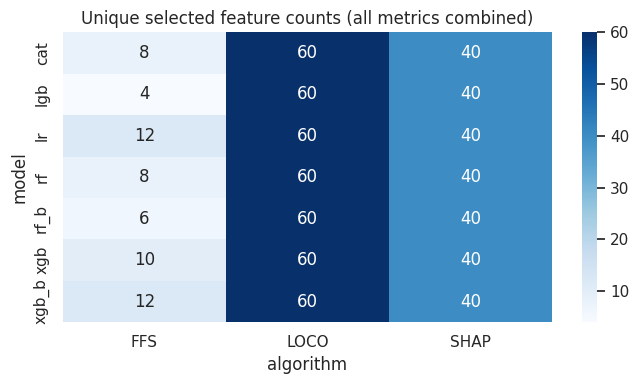

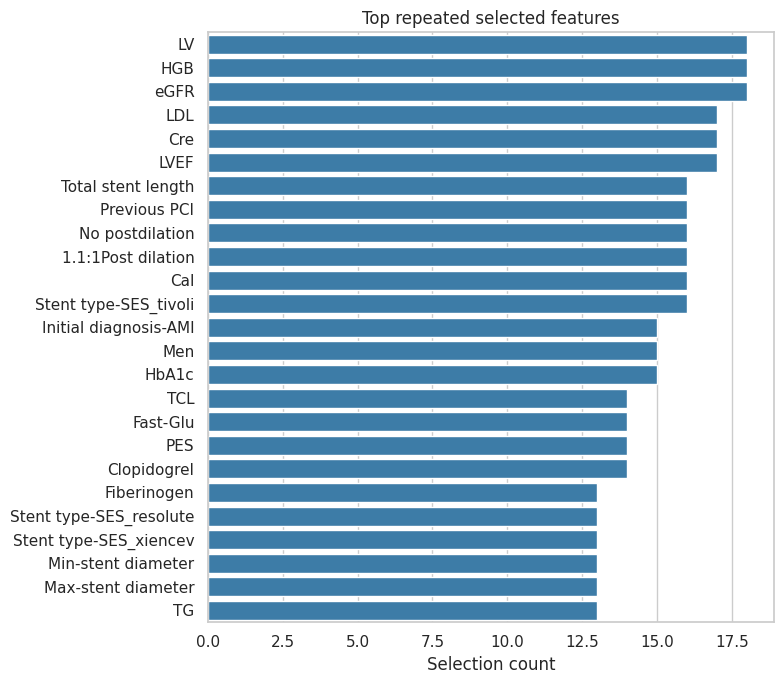

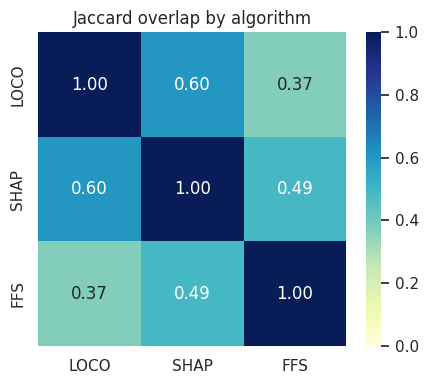

Saved outputs to /kaggle/working/model_feature_selectors_antileak
- selector_all_unique_features.csv
- selector_common_features_by_algorithm.csv
- selector_summary_long.csv
- selector_report.md
- selector_common_by_model_algorithms.csv
- selector_common_global_all_models_algorithms.csv
- selector_priority_feature_ranks.csv
- selector_union_by_model.csv
- selector_union_all_models_algorithms.csv


,feature
0,1.1:1Post dilation
1,2-vessel disease
2,3-vessel disease
3,Age
4,Aneurysm


,algorithm,metric,n_common,features
0,LOCO,pr_auc,2,Cre; eGFR
1,SHAP,pr_auc,4,Cre; HGB; LDL; eGFR
2,FFS,pr_auc,0,


,model,metric,n_common,features
0,cat,pr_auc,5,Clopidogrel; HbA1c; LDL; LV; No postdilation
1,lgb,pr_auc,1,HbA1c
2,lr,pr_auc,4,Clopidogrel; Cre; Men; eGFR
3,rf,pr_auc,3,HGB; LDL; LV
4,rf_b,pr_auc,2,Cre; eGFR
5,xgb,pr_auc,2,HGB; eGFR
6,xgb_b,pr_auc,4,Cre; HGB; Stent type-SES_xiencev; eGFR


,scope,n_common,features
0,all_models_all_algorithms,0,


,model,algorithm,metric,feature,rank,in_topk
0,cat,LOCO,pr_auc,"Age, years",NaN,False
1,cat,LOCO,pr_auc,Male sex,NaN,False
2,cat,LOCO,pr_auc,Current drinking,50.0,True
3,cat,LOCO,pr_auc,Diabetes mellitus,NaN,False
4,cat,LOCO,pr_auc,aspirin,NaN,False
5,cat,LOCO,pr_auc,Hypertension,9.0,True
6,cat,LOCO,pr_auc,Dapt,NaN,False
7,cat,LOCO,pr_auc,Dyslipidemia,NaN,False
8,cat,LOCO,pr_auc,HbA1C,NaN,False
9,cat,LOCO,pr_auc,Clopidogrel,10.0,True


,model,n_union_features,features
0,cat,33,1.1:1Post dilation; Bifurcation; CKD5; Clopido...
1,lgb,32,1.1:1Post dilation; CaI; Clopidogrel; Cre; Cur...
2,lr,33,CKD5; CKD60; Chronic total occlusion; Clopidog...
3,rf,31,1.1:1Post dilation; CKD90; CaI; Clopidogrel; C...
4,rf_b,34,1.1:1Post dilation; CKD5; CKD90; CaI; Clopidog...
5,xgb,33,1.1:1Post dilation; Bifurcation; CaI; Cardioge...
6,xgb_b,32,1.1:1Post dilation; Age; CKD5; CaI; Cardiogeni...


,scope,n_union_features,features
0,all_models_all_algorithms_union,86,1.1:1Post dilation; 2-vessel disease; 3-vessel...


In [10]:
# -------------------------------
# Final requested lists + report + compact plots
# -------------------------------

def topk_features(df, algorithm, model, metric, k=FEATURE_TOPK):
    sub = df[(df["algorithm"] == algorithm) & (df["model"] == model) & (df["metric"] == metric)]
    sub = sub.sort_values("rank").head(k)
    return set(sub["feature"].tolist())


all_unique = sorted(selector_summary_long["feature"].unique().tolist())
all_unique_df = pd.DataFrame({"feature": all_unique})
all_unique_df.to_csv(OUT_DIR / "selector_all_unique_features.csv", index=False)

models = sorted(selector_summary_long["model"].unique().tolist())
algorithms = ["LOCO", "SHAP", "FFS"]

rows = []
for algo in algorithms:
    for metric in SCORINGS:
        sets = [topk_features(selector_summary_long, algo, m, metric, FEATURE_TOPK) for m in models]
        common = sorted(set.intersection(*sets) if sets else set())
        rows.append({
            "algorithm": algo,
            "metric": metric,
            "n_common": len(common),
            "features": "; ".join(common),
        })

common_df = pd.DataFrame(rows)
common_df.to_csv(OUT_DIR / "selector_common_features_by_algorithm.csv", index=False)

required_cols = {"model", "algorithm", "metric", "rank", "feature"}
missing = required_cols - set(selector_summary_long.columns)
assert not missing, f"selector_summary_long missing required columns: {missing}"

# Optional across-metrics common per algorithm
rows2 = []
for algo in algorithms:
    sets = []
    for m in models:
        s = set()
        for metric in SCORINGS:
            s |= topk_features(selector_summary_long, algo, m, metric, FEATURE_TOPK)
        sets.append(s)
    common = sorted(set.intersection(*sets) if sets else set())
    rows2.append({"algorithm": algo, "scope": "across_metrics", "n_common": len(common), "features": "; ".join(common)})
common_across_df = pd.DataFrame(rows2)

# Common features across algorithms for each model, per metric
rows3 = []
for model in models:
    for metric in SCORINGS:
        sets = [
            topk_features(selector_summary_long, algo, model, metric, FEATURE_TOPK)
            for algo in algorithms
        ]
        common = sorted(set.intersection(*sets) if sets else set())
        rows3.append({
            "model": model,
            "metric": metric,
            "n_common": len(common),
            "features": "; ".join(common),
        })
common_by_model_algorithms_df = pd.DataFrame(rows3)
common_by_model_algorithms_df.to_csv(OUT_DIR / "selector_common_by_model_algorithms.csv", index=False)

# Global common features across all models and all algorithms (and all metrics)
global_sets = []
for model in models:
    for algo in algorithms:
        s = set()
        for metric in SCORINGS:
            s |= topk_features(selector_summary_long, algo, model, metric, FEATURE_TOPK)
        global_sets.append(s)
common_global_all = sorted(set.intersection(*global_sets) if global_sets else set())
global_common_df = pd.DataFrame({
    "scope": ["all_models_all_algorithms"],
    "n_common": [len(common_global_all)],
    "features": ["; ".join(common_global_all)],
})
global_common_df.to_csv(OUT_DIR / "selector_common_global_all_models_algorithms.csv", index=False)

# Requested: rank of priority features for each algorithm and each model
rank_rows = []
for model in models:
    for algo in algorithms:
        for metric in SCORINGS:
            sub = selector_summary_long[
                (selector_summary_long["model"] == model)
                & (selector_summary_long["algorithm"] == algo)
                & (selector_summary_long["metric"] == metric)
                ][["feature", "rank"]]
            rank_map = dict(zip(sub["feature"], sub["rank"]))
            for feature in PRIORITY_FEATURES:
                rank_rows.append({
                    "model": model,
                    "algorithm": algo,
                    "metric": metric,
                    "feature": feature,
                    "rank": rank_map.get(feature, np.nan),
                    "in_topk": feature in rank_map,
                })
priority_feature_ranks_df = pd.DataFrame(rank_rows)
priority_feature_ranks_df.to_csv(OUT_DIR / "selector_priority_feature_ranks.csv", index=False)

# Requested: union of features of all algorithms for each model
union_rows = []
for model in models:
    feat_union = set()
    for algo in algorithms:
        for metric in SCORINGS:
            feat_union |= topk_features(selector_summary_long, algo, model, metric, FEATURE_TOPK)
    union_rows.append({
        "model": model,
        "n_union_features": len(feat_union),
        "features": "; ".join(sorted(feat_union)),
    })
model_union_df = pd.DataFrame(union_rows)
model_union_df.to_csv(OUT_DIR / "selector_union_by_model.csv", index=False)

# Requested: union of all features of all models and algorithms
all_models_algorithms_union_df = pd.DataFrame({
    "scope": ["all_models_all_algorithms_union"],
    "n_union_features": [len(all_unique)],
    "features": ["; ".join(all_unique)],
})
all_models_algorithms_union_df.to_csv(OUT_DIR / "selector_union_all_models_algorithms.csv", index=False)

# Plot: model x algorithm counts (top-K records)
count_df = (
    selector_summary_long
    .groupby(["model", "algorithm"], as_index=False)["feature"]
    .nunique()
    .rename(columns={"feature": "n_unique_features"})
)
pivot_counts = count_df.pivot(index="model", columns="algorithm", values="n_unique_features").fillna(0)
plt.figure(figsize=(7, 4))
sns.heatmap(pivot_counts, annot=True, fmt=".0f", cmap="Blues")
plt.title("Unique selected feature counts (all metrics combined)")
plt.tight_layout()
plt.savefig(OUT_DIR / "selector_model_algorithm_counts.png", dpi=150)
plt.show()

# Plot: top repeated features
feat_freq = (
    selector_summary_long
    .groupby("feature", as_index=False)
    .size()
    .sort_values("size", ascending=False)
    .head(25)
)
plt.figure(figsize=(8, 7))
sns.barplot(data=feat_freq, y="feature", x="size", color="#2c7fb8")
plt.title("Top repeated selected features")
plt.xlabel("Selection count")
plt.ylabel("")
plt.tight_layout()
plt.savefig(OUT_DIR / "selector_top_repeated_features.png", dpi=150)
plt.show()

# Minimal Jaccard overlap heatmap (algorithm-level, all model/metric top-k unions)
unions = {}
for algo in algorithms:
    s = set()
    for m in models:
        for metric in SCORINGS:
            s |= topk_features(selector_summary_long, algo, m, metric, FEATURE_TOPK)
    unions[algo] = s

jacc = pd.DataFrame(index=algorithms, columns=algorithms, dtype=float)
for a in algorithms:
    for b in algorithms:
        u = unions[a] | unions[b]
        jacc.loc[a, b] = (len(unions[a] & unions[b]) / len(u)) if len(u) else 1.0

plt.figure(figsize=(4.5, 4))
sns.heatmap(jacc.astype(float), annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Jaccard overlap by algorithm")
plt.tight_layout()
plt.savefig(OUT_DIR / "selector_overlap_heatmap.png", dpi=150)
plt.show()

# Markdown report
report_lines = [
    "# Multi-Model Feature Selector Report",
    "",
    f"Generated: {time.strftime('%Y-%m-%d %H:%M:%S')}",
    "",
    "## Split check (full-cohort fit / inner-val; no unused outer test)",
    "",
    f"- n_total={split_manifest['n_total']}, n_fit={split_manifest['n_fit']}, n_val={split_manifest['n_val']}",
    f"- fit_pos={split_manifest['fit_pos']}, val_pos={split_manifest['val_pos']}",
    "",
    "## Models",
    "",
    f"- {', '.join(models)}",
    "",
    "## All unique selected features",
    "",
    f"- count={len(all_unique)}",
    "",
    "## Common features across all models per algorithm and metric",
    "",
]
for _, r in common_df.iterrows():
    report_lines.append(f"- {r['algorithm']} | {r['metric']} | n_common={int(r['n_common'])} | {r['features']}")

report_lines.extend(["", "## Common features across all models per algorithm (across metrics)", ""])
for _, r in common_across_df.iterrows():
    report_lines.append(f"- {r['algorithm']} | n_common={int(r['n_common'])} | {r['features']}")

report_lines.extend(["", "## Common features across algorithms for each model", ""])
for _, r in common_by_model_algorithms_df.iterrows():
    report_lines.append(
        f"- {r['model']} | {r['metric']} | LOCO∩SHAP∩FFS n_common={int(r['n_common'])} | {r['features']}"
    )

report_lines.extend(["", "## Global common features across all models and all algorithms", ""])
report_lines.append(
    f"- n_common={int(global_common_df['n_common'].iloc[0])} | {global_common_df['features'].iloc[0]}"
)

report_lines.extend(["", "## Priority feature ranks by model, algorithm, and metric", ""])
for model in models:
    report_lines.append("")
    report_lines.append(f"### {model}")
    model_rank_df = priority_feature_ranks_df[priority_feature_ranks_df["model"] == model]
    for algo in algorithms:
        report_lines.append(f"- **{algo}**")
        for metric in SCORINGS:
            sub = model_rank_df[(model_rank_df["algorithm"] == algo) & (model_rank_df["metric"] == metric)]
            rank_bits = []
            for _, row in sub.iterrows():
                rank_val = "NA" if pd.isna(row["rank"]) else int(row["rank"])
                rank_bits.append(f"{row['feature']}={rank_val}")
            report_lines.append(f"  - {metric}: " + ", ".join(rank_bits))

report_lines.extend(["", "## Union of features of all algorithms for each model", ""])
for _, r in model_union_df.iterrows():
    report_lines.append(
        f"- {r['model']} | n_union_features={int(r['n_union_features'])} | {r['features']}"
    )

report_lines.extend(["", "## Union of all features of all models and algorithms", ""])
report_lines.append(
    f"- n_union_features={int(all_models_algorithms_union_df['n_union_features'].iloc[0])} | {all_models_algorithms_union_df['features'].iloc[0]}"
)

(OUT_DIR / "selector_report.md").write_text("\n".join(report_lines), encoding="utf-8")

print("Saved outputs to", OUT_DIR)
print("- selector_all_unique_features.csv")
print("- selector_common_features_by_algorithm.csv")
print("- selector_summary_long.csv")
print("- selector_report.md")
print("- selector_common_by_model_algorithms.csv")
print("- selector_common_global_all_models_algorithms.csv")
print("- selector_priority_feature_ranks.csv")
print("- selector_union_by_model.csv")
print("- selector_union_all_models_algorithms.csv")

display(all_unique_df.head())
display(common_df)
display(common_by_model_algorithms_df)
display(global_common_df)
display(priority_feature_ranks_df.head(20))
display(model_union_df)
display(all_models_algorithms_union_df)


## Notes

- **Kaggle GPU:** In notebook settings, enable **GPU T4 x2** and Internet. Re-run the first config cell; you should see `GPU: True | Tesla T4`.
- GPU helps **CatBoost, XGBoost, LightGBM, TabPFN**. LR/RF stay CPU-only.
- One paper protocol only (top-20, SHAP 40 permutations, FFS 24×12, 400 boosting rounds). There is no reduced budget.
- **Selectors use the full cohort.** LOCO / SHAP / FFS fit on `1 - INNER_VAL_SIZE` and score on the rest. There is no parked outer test. Delete old cached CSVs; `USE_CACHE=False`.
- **Independent selectors, PR-AUC only.** Flip `RUN_SELECTORS` to skip a method. FFS uses its own cheap-importance pool (`FFS_CANDIDATE_POOL=24`) and stops after `FFS_MAX_STEPS=12` or when PR-AUC stops rising (~222 refits/model before early stop).
- If CatBoost GPU fails, the wrapper automatically retries on CPU.
- If `tabpfn` is unavailable (package/token), the notebook continues with the other models.

- **Anti-leakage (this code):** drop TSSI and WBC; quantize Cre/CaI/Fiberinogen/Fast-Glu; stent collapse and scaler/OHE fit on the **fit slice only**. New CSVs go to `model_feature_selectors_antileak/`. Stored outputs in this notebook remain the previous leaky-WBC run until you re-execute.
